In [1]:
from libraries import *

In [2]:
gp.setParam("OutputFlag", 0) # Disables Gurobi logs (Affects all models created afterward)

Set parameter Username
Set parameter LicenseID to value 2739131
Academic license - for non-commercial use only - expires 2026-11-14


     Time_s  Longitude_deg  Latitude_deg   Altitude_m
0       0.0     279.000000     49.000000  25000.00000
1    3600.0     278.974006     49.042329  23672.57558
4    7200.0     278.932833     49.055108  22986.64633
7   10800.0     278.900893     49.018890  19378.08451
10  14400.0     278.989935     48.980466  20387.52864
13  18000.0     279.006678     48.992932  21378.46182
16  21600.0     279.038680     49.008456  21722.88519
19  25200.0     279.061682     49.024487  23068.06755
22  28800.0     279.067620     49.034208  22980.28988
25  32400.0     279.080779     49.013625  23209.52264
28  36000.0     279.075842     48.996233  23206.76795
31  39600.0     279.055069     48.999030  23206.48967
34  43200.0     279.049362     48.977709  23429.46557
37  46800.0     279.054583     49.001266  22740.73417
40  50400.0     278.985247     48.953397  21049.70677
43  54000.0     278.919923     48.953306  20474.85927
46  57600.0     278.939021     48.977959  19860.05593
49  61200.0     278.994659  

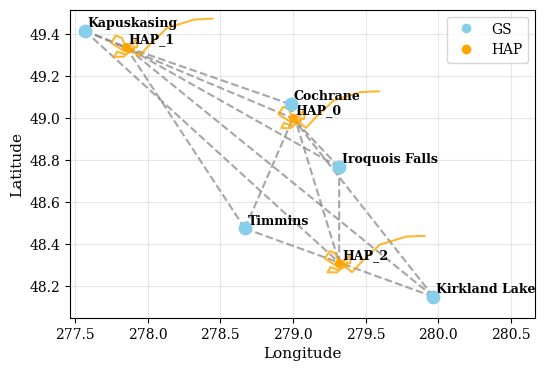

⏱️ Calculating K_MAX from t=0 to t=23 (24 time steps)
[INFO] Loaded checkpoint from K_MAX_checkpoint.pkl
✅ Requested interval [0, 24) fully covered in checkpoint.


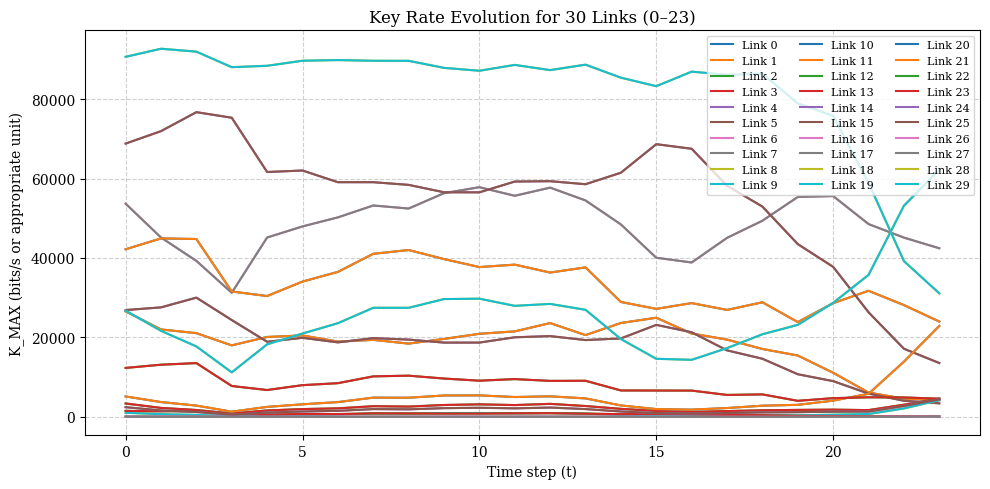

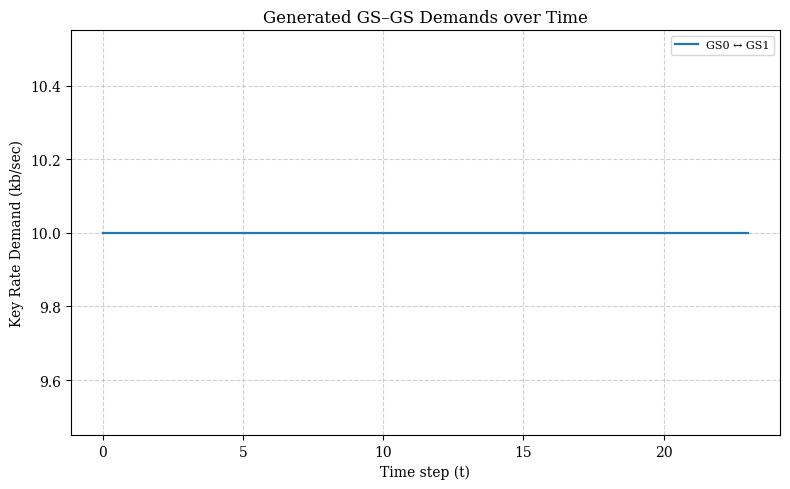

In [3]:
gnodes, hnodes, links, demands = init_setup_real()

In [4]:
# Initialize state and action
state  = [{} for _ in syst.T]
action = [{} for _ in syst.T]
reward = [0  for _ in syst.T]

state[0]["demands"] = demands
state[0]["a"] = {i: 0 for i in range(len(links))}

In [5]:
# ---------- Hyperparams ----------
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP = 0.2
LR = 3e-4
EPOCHS = 4
BATCH_SIZE = 64
ENTROPY_COEF_INITIAL = 0.05         # >>> CHANGE - will decay over training
ENTROPY_COEF_MIN = 0.001            # >>> CHANGE
ENTROPY_DECAY = 0.995               # >>> CHANGE
VALUE_COEF = 0.5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

entropy_coef = ENTROPY_COEF_INITIAL  # >>> CHANGE

print(f"len(gnodes): {len(gnodes)}")

def build_state_vector_for_time(state_t, links, t, n_nodes=len(gnodes), normalize=True):
    """
    Build state vector for the QKD environment.

    state_t["a"]: dict or list of QKP (stored key bits) for each link.
    state_t["demands"]: list of demand objects with attributes (K_REQ, n1, n2).

    Output vector structure:
        [ QKP_link0, ..., QKP_linkL-1,
          onehot_src_demand0..., onehot_dst_demand0..., KREQ_0,
          onehot_src_demand1..., onehot_dst_demand1..., KREQ_1,
          ... ]

    Args:
        state_t: dict for time t
        links: list of link objects (or identifiers)
        n_nodes: total number of GS/HAP nodes (used for one-hot encoding)
        normalize: normalize QKP and KREQ values to [0, 1] range if True
    """
    # --- QKP per link ---
    a_vec = np.array(
        [state_t.get("a", {}).get(l, 0.0) for l in range(len(links))],
        dtype=np.float32
    )

    # normalize QKP values if desired
    if normalize and len(a_vec) > 0:
        max_qkp = np.max(a_vec) if np.max(a_vec) > 0 else 1.0
        a_vec = a_vec / max_qkp

    # --- Encode demands ---
    d_vec = []
    for d in state_t.get("demands", []):
        # normalize K_REQ
        kreq = float(d.K_REQ[t])
        if normalize and kreq > 0:
            kreq = kreq / (kreq + 1e-6)  # simple scaling to (0,1)
        # one-hot encode endpoints if n_nodes provided
        if n_nodes is not None:
            onehot_src = np.zeros(n_nodes, dtype=np.float32)
            onehot_dst = np.zeros(n_nodes, dtype=np.float32)
            if 0 <= gnodes.index(d.n1) < n_nodes:
                onehot_src[gnodes.index(d.n1)] = 1.0
            if 0 <= gnodes.index(d.n2) < n_nodes:
                onehot_dst[gnodes.index(d.n2)] = 1.0
            d_vec.extend(onehot_src.tolist() + onehot_dst.tolist() + [kreq])
        else:
            # fallback to simpler encoding if node info omitted
            d_vec.append(kreq)

    # --- Concatenate ---
    state_vector = np.concatenate([a_vec, np.array(d_vec, dtype=np.float32)])
    return state_vector

# >>> ADD utility to build binary mask of feasible actions
def build_action_mask(links, demands, gnodes, hnodes, state_t):
    mask = np.ones(n_links * n_demands, dtype=np.float32)

    # try to activate each link-demand action hypothetically and see if feasible
    for idx_l, l in enumerate(links):
        for idx_d, d in enumerate(demands):
            flat_idx = idx_l * n_demands + idx_d

            # count TX/RX usage if this action is taken
            tx_ok = state_t["a"].get(idx_l, 0) <= l.n1.N_TX - 1
            rx_ok = state_t["a"].get(idx_l, 0) <= l.n2.N_RX - 1

            if not (tx_ok and rx_ok):
                mask[flat_idx] = 0.0
    return mask

# ---------- Actor-Critic network for multi-binary action ----------
class ActorCriticBinary(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )
        # outputs logits for Bernoulli per action dimension
        self.logit_head = nn.Linear(hidden, action_dim)
        # critic outputs a scalar value
        self.critic = nn.Sequential(
            nn.Linear(state_dim, hidden//2),
            nn.ReLU(),
            nn.Linear(hidden//2, 1)
        )

    def forward(self, state):
        """
        state: tensor of shape [batch, state_dim]
        returns:
            logits: [batch, action_dim]
            value: [batch, 1]
        """
        h = self.net(state)
        logits = self.logit_head(h)
        value = self.critic(state)
        return logits, value.squeeze(-1)

# ---------- PPO Agent for binary actions ----------
class PPOBinaryAgent:
    def __init__(self, state_dim, action_dim, lr=LR):
        self.model = ActorCriticBinary(state_dim, action_dim).to(DEVICE)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.action_dim = action_dim

    def select_action(self, state_vec, mask=None):
        s = torch.tensor(state_vec, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        logits, value = self.model(s)  # [1, action_dim], [1]

        # >>> CHANGE — apply action mask BEFORE sampling
        if mask is not None:
            # mask=1 allowed, mask=0 blocked
            mask = torch.tensor(mask, dtype=torch.float32, device=DEVICE)
            blocked = (mask == 0)
            logits = logits.masked_fill(blocked, -1e9)

        probs = torch.sigmoid(logits)
        m = torch.distributions.Bernoulli(probs)
        action = m.sample()
        logp = m.log_prob(action).sum(dim=-1)

        return action.squeeze(0).cpu().numpy().astype(int), logp.squeeze(0).detach(), value.squeeze(0).detach()

    def compute_gae(self, rewards, values, dones, gamma=GAMMA, lam=GAE_LAMBDA):
        # rewards: list length T
        # values: tensor shape [T+1] containing state values; values[-1] is bootstrap for final
        T = len(rewards)
        adv = torch.zeros(T, device=DEVICE)
        lastgaelam = 0
        for t in reversed(range(T)):
            nonterminal = 1.0 - dones[t]
            delta = rewards[t] + gamma * values[t+1] * nonterminal - values[t]
            lastgaelam = delta + gamma * lam * nonterminal * lastgaelam
            adv[t] = lastgaelam
        returns = adv + values[:-1]
        return adv, returns

    def update(self, states, actions, old_logps, returns, advantages, entropy_coef):  # >>> CHANGE - new param
        """
        states: tensor [N, state_dim]
        actions: tensor [N, action_dim] (0/1)
        old_logps: tensor [N] (scalar log prob of full action vector)
        returns: tensor [N]
        advantages: tensor [N]
        """
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        N = states.shape[0]
        idxs = np.arange(N)
        for _ in range(EPOCHS):
            np.random.shuffle(idxs)
            for start in range(0, N, BATCH_SIZE):
                batch_idx = idxs[start:start + BATCH_SIZE]
                b_states = states[batch_idx].to(DEVICE)
                b_actions = actions[batch_idx].to(DEVICE).float()
                b_old_logps = old_logps[batch_idx].to(DEVICE)
                b_returns = returns[batch_idx].to(DEVICE)
                b_adv = advantages[batch_idx].to(DEVICE)

                logits, values = self.model(b_states)
                probs = torch.sigmoid(logits)
                dist = torch.distributions.Bernoulli(probs)
                new_logp = dist.log_prob(b_actions).sum(dim=-1)
                entropy = dist.entropy().sum(dim=-1).mean()

                ratio = torch.exp(new_logp - b_old_logps)
                surr1 = ratio * b_adv
                surr2 = torch.clamp(ratio, 1.0 - CLIP, 1.0 + CLIP) * b_adv
                actor_loss = -torch.min(surr1, surr2).mean()
                critic_loss = F.mse_loss(values, b_returns)

                loss = actor_loss + VALUE_COEF * critic_loss - entropy_coef * entropy  # >>> CHANGE

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

len(gnodes): 5


Episode 1/2000, total reward: -42.875, entropy_coef: 0.0498
Episode 2/2000, total reward: -44.750, entropy_coef: 0.0495
Episode 3/2000, total reward: -44.875, entropy_coef: 0.0493
Episode 4/2000, total reward: -44.375, entropy_coef: 0.0490
Episode 5/2000, total reward: -43.500, entropy_coef: 0.0488
Episode 6/2000, total reward: -46.625, entropy_coef: 0.0485
Episode 7/2000, total reward: -44.750, entropy_coef: 0.0483
Episode 8/2000, total reward: -45.500, entropy_coef: 0.0480
Episode 9/2000, total reward: -47.000, entropy_coef: 0.0478
Episode 10/2000, total reward: -44.000, entropy_coef: 0.0476
Episode 11/2000, total reward: -43.875, entropy_coef: 0.0473
Episode 12/2000, total reward: -44.875, entropy_coef: 0.0471
Episode 13/2000, total reward: -45.250, entropy_coef: 0.0468
Episode 14/2000, total reward: -44.250, entropy_coef: 0.0466
Episode 15/2000, total reward: -43.250, entropy_coef: 0.0464
Episode 16/2000, total reward: -47.750, entropy_coef: 0.0461
Episode 17/2000, total reward: -4

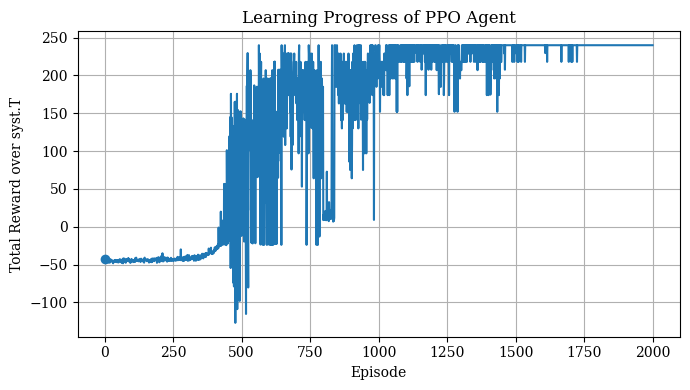

In [6]:
# prepare agent
n_links = len(links)
n_demands = len(demands)   # assume constant across T
action_dim = n_links * n_demands

# choose state_dim produced by build_state_vector_for_time
state_vector_example = build_state_vector_for_time(state[0], links, 0)
state_dim = len(state_vector_example)

agent = PPOBinaryAgent(state_dim, action_dim, lr=LR)

# Training hyperparams
num_episodes = 2000
episode_len = len(syst.T)

# Track total rewards per episode
episode_rewards = []

solution = {"a": state[0]["a"].copy()}

for ep in range(num_episodes):
    # reset state & action containers
    state = [{} for _ in syst.T]
    action = [{} for _ in syst.T]
    state[0]["demands"] = demands.copy()
    state[0]["a"] = {i: 0 for i in range(n_links)}

    # rollout buffers
    states_buf = []
    actions_buf = []
    logps_buf = []
    rewards_buf = []
    dones_buf = []
    values_buf = []

    total_reward = 0.0

    for t in syst.T:
        # >>> NEW — build action mask before selecting action
        mask = build_action_mask(links, demands, gnodes, hnodes, state[t])
        s_vec = build_state_vector_for_time(state[t], links, t)

        action_vec, logp, value = agent.select_action(s_vec, mask=mask)   # >>> CHANGE

        # convert flat action vector to dictionary
        action[t] = {}
        for idx_l in range(n_links):
            for idx_d in range(len(state[t]["demands"])):
                flat_idx = idx_l * n_demands + idx_d
                action[t][(idx_l, idx_d)] = int(action_vec[flat_idx])

        # call your environment / model
        # Maximum Tx/Rx Connection
        check_tx, check_rx = 1, 1
        sum_tx, sum_rx = {}, {}

        nodes = gnodes + hnodes
        for idx_n, n in enumerate(nodes):
            sum_tx[idx_n] = sum(action[t][(idx_l, idx_d)]
                                for idx_l, l in enumerate(links)
                                for idx_d, d in enumerate(demands)
                                if  l.n1 == n
                               )

            sum_rx[idx_n] = sum(action[t][(idx_l, idx_d)]
                                for idx_l, l in enumerate(links)
                                for idx_d, d in enumerate(demands)
                                if  l.n1 == n
                               )
            
            check_tx = check_tx and (sum_tx[idx_n] <= n.N_TX)
            check_rx = check_rx and (sum_rx[idx_n] <= n.N_RX)

            # if not check_tx or not check_rx:
            #     # print("Violated maximum RX/TX constraints!")
            #     break

        if check_tx and check_rx:
            solution, reward_t = online_new(gnodes, hnodes, links, state, action, t, 1)
        else:
            reward_t = -sum(sum_tx[idx_n] + sum_rx[idx_n] for idx_n, n in enumerate(nodes)) / len(nodes) / 2 #-10

        reward[t] = reward_t
        total_reward += reward_t

        # store rollout data
        states_buf.append(torch.tensor(s_vec, dtype=torch.float32))
        actions_buf.append(torch.tensor(action_vec, dtype=torch.float32))
        logps_buf.append(logp)
        values_buf.append(value)
        rewards_buf.append(torch.tensor(float(reward_t), dtype=torch.float32))
        dones_buf.append(torch.tensor(0.0))

        # step to next state
        if t + 1 < episode_len:
            if check_tx and check_rx:
                state[t+1]["a"] = solution["a"]
            else:
                state[t+1]["a"] = state[t]["a"]
            state[t+1]["demands"] = state[t]["demands"]

    # bootstrap final value
    final_s_vec = build_state_vector_for_time(state[-1], links, t)
    with torch.no_grad():
        _, final_value = agent.model(torch.tensor(final_s_vec, dtype=torch.float32, device=DEVICE).unsqueeze(0))
    values_tensor = torch.stack(values_buf).to(DEVICE)
    values_tensor = torch.cat([values_tensor, final_value.view(1)])   # shape [T+1]

    rewards_tensor = torch.stack(rewards_buf).to(DEVICE)
    dones_tensor = torch.stack(dones_buf).to(DEVICE)

    advantages, returns = agent.compute_gae(rewards_tensor, values_tensor, dones_tensor)

    # prepare PPO update batches
    states_b = torch.stack(states_buf)
    actions_b = torch.stack(actions_buf)
    old_logps_b = torch.stack(logps_buf).to(DEVICE)
    returns_b = returns.detach()
    adv_b = advantages.detach()

    # >>> adaptive entropy scheduling (slower exploration over time)
    entropy_coef = max(entropy_coef * ENTROPY_DECAY, ENTROPY_COEF_MIN)

    agent.update(states_b, actions_b, old_logps_b, returns_b, adv_b, entropy_coef)  # >>> CHANGE

    # store total reward for this episode
    episode_rewards.append(total_reward)

    # print progress
    print(f"Episode {ep+1}/{num_episodes}, total reward: {total_reward:.3f}, entropy_coef: {entropy_coef:.4f}")

# === Plot learning curve ===
plt.figure(figsize=(7,4))
plt.plot(range(1, num_episodes+1), episode_rewards, marker='o', markevery=num_episodes/10, linewidth=1.5)
plt.xlabel("Episode")
plt.ylabel("Total Reward over syst.T")
plt.title("Learning Progress of PPO Agent")
plt.grid(True)
plt.tight_layout()
plt.show()

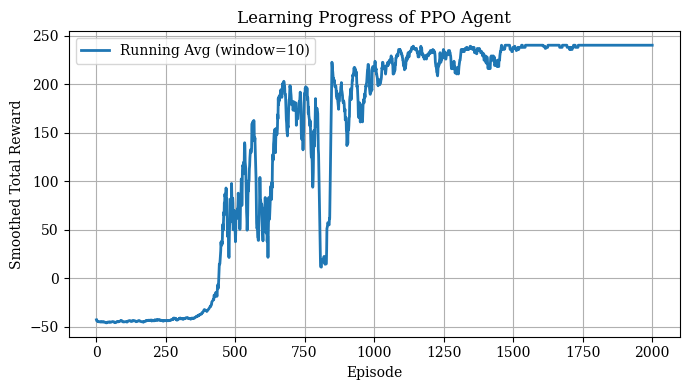

In [7]:
# === Plot learning curve with running average ===
window = 10                     # moving average window (change as desired)
running_avg = []

for i in range(len(episode_rewards)):
    start = max(0, i - window + 1)
    running_avg.append(np.mean(episode_rewards[start:i+1]))

plt.figure(figsize=(7,4))
plt.plot(range(1, num_episodes+1), running_avg, linewidth=2, label=f"Running Avg (window={window})")
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title("Learning Progress of PPO Agent")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [8]:
# # ============================================================
# # 1️⃣  Actor-Critic Network
# # ============================================================
# class ActorCritic(nn.Module):
#     def __init__(self, state_dim, action_dim):
#         super().__init__()
#         self.actor = nn.Sequential(
#             nn.Linear(state_dim, 64),
#             nn.ReLU(),
#             nn.Linear(64, action_dim),
#             nn.Softmax(dim=-1)
#         )
#         self.critic = nn.Sequential(
#             nn.Linear(state_dim, 64),
#             nn.ReLU(),
#             nn.Linear(64, 1)
#         )

#     def forward(self, state):
#         probs = self.actor(state)
#         value = self.critic(state)
#         return probs, value


# # ============================================================
# # 2️⃣  PPO Agent
# # ============================================================
# class PPOAgent:
#     def __init__(self, state_dim, action_dim, lr=3e-4, gamma=0.99, eps_clip=0.2):
#         self.gamma = gamma
#         self.eps_clip = eps_clip

#         self.model = ActorCritic(state_dim, action_dim)
#         self.optimizer = optim.Adam(self.model.parameters(), lr=lr)

#     def select_action(self, state):
#         state = torch.tensor(state, dtype=torch.float32)
#         probs, value = self.model(state)
#         dist = torch.distributions.Categorical(probs)
#         action = dist.sample()
#         return action.item(), dist.log_prob(action), value

#     def compute_advantages(self, rewards, values, dones):
#         advantages = []
#         gae = 0
#         values = values.detach().numpy()  # Detach to avoid autograd graph reuse
#         for t in reversed(range(len(rewards))):
#             delta = rewards[t] + self.gamma * values[t + 1] * (1 - dones[t]) - values[t]
#             gae = delta + self.gamma * 0.95 * (1 - dones[t]) * gae
#             advantages.insert(0, gae)
#         return torch.tensor(advantages, dtype=torch.float32)

#     def update(self, states, actions, log_probs_old, returns, advantages, epochs=5, batch_size=32):
#         advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

#         dataset_size = len(states)
#         for _ in range(epochs):
#             indices = np.arange(dataset_size)
#             np.random.shuffle(indices)

#             for start in range(0, dataset_size, batch_size):
#                 end = start + batch_size
#                 batch_idx = indices[start:end]

#                 batch_states = states[batch_idx]
#                 batch_actions = actions[batch_idx]
#                 batch_log_probs_old = log_probs_old[batch_idx]
#                 batch_advantages = advantages[batch_idx]
#                 batch_returns = returns[batch_idx]

#                 probs, values = self.model(batch_states)
#                 dist = torch.distributions.Categorical(probs)
#                 log_probs = dist.log_prob(batch_actions)

#                 ratios = torch.exp(log_probs - batch_log_probs_old.detach())
#                 surr1 = ratios * batch_advantages
#                 surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * batch_advantages
#                 actor_loss = -torch.min(surr1, surr2).mean()

#                 #critic_loss = F.mse_loss(values.squeeze(), batch_returns)
#                 critic_loss = F.mse_loss(values.view_as(batch_returns), batch_returns)

#                 entropy_loss = dist.entropy().mean()

#                 loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy_loss

#                 self.optimizer.zero_grad()
#                 loss.backward()
#                 self.optimizer.step()


# # ============================================================
# # 3️⃣  Training Loop
# # ============================================================
# env = gym.make("CartPole-v1")

# state_dim = env.observation_space.shape[0]
# action_dim = env.action_space.n
# agent = PPOAgent(state_dim, action_dim)

# num_episodes = 100
# reward_history = []

# for ep in range(num_episodes):
#     state, _ = env.reset()
#     done = False

#     states, actions, log_probs, rewards, values, dones = [], [], [], [], [], []

#     while not done:
#         action, log_prob, value = agent.select_action(state)

#         next_state, reward, done, _, _ = env.step(action)

#         # Store transition
#         states.append(torch.tensor(state, dtype=torch.float32))
#         actions.append(torch.tensor(action))
#         log_probs.append(log_prob.detach())  # Detach avoids autograd reuse
#         values.append(value.detach())        # Detach avoids autograd reuse
#         rewards.append(reward)
#         dones.append(float(done))

#         state = next_state

#     # Bootstrap final state value
#     with torch.no_grad():
#         _, next_value = agent.model(torch.tensor(state, dtype=torch.float32))
#     values.append(next_value.detach())

#     # Convert to tensors
#     rewards = torch.tensor(rewards, dtype=torch.float32)
#     values = torch.stack(values).squeeze()
#     dones = torch.tensor(dones, dtype=torch.float32)

#     advantages = agent.compute_advantages(rewards, values, dones)
#     returns = advantages + values[:-1]

#     # Stack rollout data
#     states = torch.stack(states)
#     actions = torch.stack(actions)
#     log_probs = torch.stack(log_probs)

#     # Update policy
#     agent.update(states, actions, log_probs, returns.detach(), advantages.detach())

#     total_reward = sum(rewards)
#     reward_history.append(total_reward)

#     if (ep + 1) % 10 == 0:
#         print(f"Episode {ep + 1}, Reward: {total_reward:.1f}, Avg(10): {np.mean(reward_history[-10:]):.1f}")

# env.close()

# # --- Plot learning curve ---
# plt.plot(reward_history)
# plt.xlabel("Episode")
# plt.ylabel("Total Reward")
# plt.title("PPO on CartPole-v1")
# plt.grid(True)
# plt.show()